## 1) Train the Naive Bayes model without PCA and compare the result with PCA + Naive Bayes. Write down your observations.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.decomposition import PCA

In [2]:
# Loading Dataset

dataset = datasets.load_digits()

x = pd.DataFrame(dataset.data,columns=dataset.feature_names)
y = dataset.target

In [3]:
# Scaling Data

scaler = StandardScaler()
x = scaler.fit_transform(x)
print(x.shape)

(1797, 64)


In [4]:
# without PCA - Train naive bayes

# Splitting dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state=36)

gnb = GaussianNB()
gnb.fit(x_train, y_train)

y_pred = gnb.predict(x_test)

print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))
print()
print(metrics.classification_report(y_test, y_pred))

Accuracy:  0.8111111111111111

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        49
           1       0.80      0.83      0.81        47
           2       1.00      0.63      0.77        51
           3       0.88      0.82      0.85        44
           4       0.97      0.59      0.73        49
           5       0.86      0.93      0.90        46
           6       0.84      1.00      0.92        38
           7       0.56      1.00      0.72        38
           8       0.64      0.84      0.73        45
           9       0.92      0.56      0.70        43

    accuracy                           0.81       450
   macro avg       0.84      0.82      0.81       450
weighted avg       0.85      0.81      0.81       450



In [5]:
# With PCA - Train naive bayes

pca = PCA(n_components=25)

x_pca = pca.fit_transform(x)
print("Shape of x_pca : ", x_pca.shape)

# Splitting data
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(x_pca, y, test_size=0.25, random_state=36)

# Train model
gnb = GaussianNB()
gnb.fit(x_train_pca, y_train_pca)

y_pred_pca =  gnb.predict(x_test_pca)

# Accuracy
print()
print("Accuracy: ", metrics.accuracy_score(y_test_pca, y_pred_pca))
print()
print(metrics.classification_report(y_test_pca, y_pred_pca))

Shape of x_pca :  (1797, 25)

Accuracy:  0.9066666666666666

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        49
           1       0.79      0.96      0.87        47
           2       1.00      0.84      0.91        51
           3       0.87      0.91      0.89        44
           4       0.97      0.80      0.88        49
           5       0.96      0.96      0.96        46
           6       0.97      0.95      0.96        38
           7       0.95      1.00      0.97        38
           8       0.80      0.78      0.79        45
           9       0.82      0.98      0.89        43

    accuracy                           0.91       450
   macro avg       0.91      0.91      0.91       450
weighted avg       0.91      0.91      0.91       450



## 2) Run PCA on IRIS dataset. Visualise the output in 2 dimensions using to Principal components. Choose different pairs of principal components and note down your observations.

In [6]:
# Load IRIS Dataset

dataset = datasets.load_iris()

x = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = dataset.target

print("Features : \n\n", x)
print()
print("Labels : \n\n", y)

Features : 

      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]

Labels : 

 [0 0 0 0 0 0 

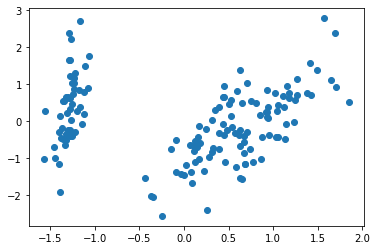

In [7]:
pca = PCA(n_components=2, whiten=True)

x_pca = pca.fit_transform(x)

x_pca = pd.DataFrame(data=x_pca, columns=['PC1','PC2'])
plt.scatter(x_pca.PC1, x_pca.PC2)
plt.show()


## 3 Run PCA + Naive Bayes classifier on IRIS dataset and calculate precision and recall of the system

In [8]:
# Splitting Data
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(x_pca, y, test_size=0.25, random_state=36)

# Train model
gnb = GaussianNB()
gnb.fit(x_train_pca, y_train_pca)

y_pred_pca =  gnb.predict(x_test_pca)

# Accuracy
print()
print("Accuracy: ", metrics.accuracy_score(y_test_pca, y_pred_pca))
print()
print(metrics.classification_report(y_test_pca, y_pred_pca))


Accuracy:  0.8947368421052632

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.69      0.82        13
           2       0.75      1.00      0.86        12

    accuracy                           0.89        38
   macro avg       0.92      0.90      0.89        38
weighted avg       0.92      0.89      0.89        38

